In [12]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Giotto-TDA imports
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

# Configuration
CLASSES = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
DATASET_DIR = "dataset"  # Replace with your actual dataset path
TARGET_SIZE = (32, 32)   # 32x32 image yields a 1024-dimensional 1D signal

print("Setup complete. Ready to extract features using Giotto-TDA.")

Setup complete. Ready to extract features using Giotto-TDA.


In [13]:
# def extract_features_single_image(image_path, target_size=TARGET_SIZE, time_delay=1, dimension=3):
#     """
#     Loads an image, flattens it to 1D, applies Takens Embedding, 
#     calculates Vietoris-Rips Homology, and extracts TDA features.
#     """
#     # Feature dimensions: Raw (1024) + TDA (100 Betti + 120 Landscape + 2 Entropy + 4 Amplitude = 226)
#     default_raw = np.zeros(target_size[0] * target_size[1])
#     default_tda = np.zeros(226)
    
#     img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#     if img is None:
#         return default_raw, default_tda
        
#     # Resize and normalize to [0, 1]
#     img_resized = cv2.resize(img, target_size)
#     raw_pixels = img_resized.flatten() / 255.0
    
#     try:
#         # 1. Phase space reconstruction via Takens Embedding
#         embedder = SingleTakensEmbedding(parameters_type="search", time_delay=time_delay, dimension=dimension)
#         point_cloud = embedder.fit_transform(raw_pixels)
        
#         # 2. Compute Vietoris-Rips Persistence Diagrams
#         vr = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=1)
#         diagrams = vr.fit_transform(np.array([point_cloud]))
        
#         # 3. Extract Topological Features
#         bc = BettiCurve(n_bins=50).fit_transform(diagrams).flatten()                  # 100 features
#         pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(diagrams).flatten() # 120 features
#         pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(diagrams).flatten()  # 2 features
#         amp_w = Amplitude(metric='wasserstein').fit_transform(diagrams).flatten()      # 2 features
#         amp_b = Amplitude(metric='bottleneck').fit_transform(diagrams).flatten()       # 2 features
        
#         tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
#         return raw_pixels, tda_features
        
#     except Exception:
#         return raw_pixels, default_tda

In [14]:
import cv2
import numpy as np
from ripser import ripser
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_single_image(image_path, target_size=(32, 32), time_delay=1, dimension=3):
    """
    Loads an image, flattens it to 1D, applies Takens Embedding, 
    calculates Vietoris-Rips Homology via direct C++ Ripser, 
    and extracts exactly 226 TDA features.
    """
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    # Resize and normalize to [0, 1]
    img_resized = cv2.resize(img, target_size)
    raw_pixels = img_resized.flatten() / 255.0
    
    try:
        # 1. Phase space reconstruction via Takens Embedding
        embedder = SingleTakensEmbedding(parameters_type="search", time_delay=time_delay, dimension=dimension)
        point_cloud = embedder.fit_transform(raw_pixels)
        
        # 2. Compute Persistence Diagrams directly via fast C++ Ripser wrapper
        ripser_res = ripser(point_cloud, maxdim=1)
        dgms = ripser_res['dgms']
        
        # 3. Format Ripser output for giotto-tda feature extractors
        # Remove infinity from H0 (essential component) to avoid NaN errors in gtda
        h0 = dgms[0][dgms[0][:, 1] != np.inf]
        h1 = dgms[1]
        
        # Add a third column representing the homology dimension (0 for H0, 1 for H1)
        if h0.shape[0] > 0:
            h0_ext = np.column_stack((h0, np.zeros(h0.shape[0])))
        else:
            h0_ext = np.empty((0, 3))
            
        if h1.shape[0] > 0:
            h1_ext = np.column_stack((h1, np.ones(h1.shape[0])))
        else:
            h1_ext = np.empty((0, 3))
            
        # Combine H0 and H1, then add the batch dimension -> shape: (1, n_points, 3)
        dgm_combined = np.vstack((h0_ext, h1_ext))
        gtda_diagrams = np.expand_dims(dgm_combined, axis=0)
        
        # 4. Extract Topological Features
        bc = BettiCurve(n_bins=50).fit_transform(gtda_diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(gtda_diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(gtda_diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(gtda_diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(gtda_diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda

In [15]:
def process_dataset_split(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    # Run parallel processing across available CPU cores
    results = Parallel(n_jobs=-1)(delayed(extract_features_single_image)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

# Execute processing for all dataset splits
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split('train')
X_val_raw, X_val_tda, y_val = process_dataset_split('val')
X_test_raw, X_test_tda, y_test = process_dataset_split('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...
[VAL] Found 1748 images. Processing...
[TEST] Found 1737 images. Processing...
Feature extraction finished successfully.


In [16]:
np.save("TRAIN_LANDSCAPES_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_y.npy", y_train)

np.save("VAL_LANDSCAPES_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_y.npy", y_val)

np.save("TEST_LANDSCAPES_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_y.npy", y_test)

=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===

[Baseline] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.88      0.94      0.91       300
Pneumonia-Bacterial       0.80      0.82      0.81       300
    Pneumonia-Viral       0.83      0.73      0.78       300
           COVID-19       0.84      0.89      0.86       300
       Tuberculosis       0.95      0.98      0.96       287
          Emphysema       0.86      0.80      0.83       250

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737



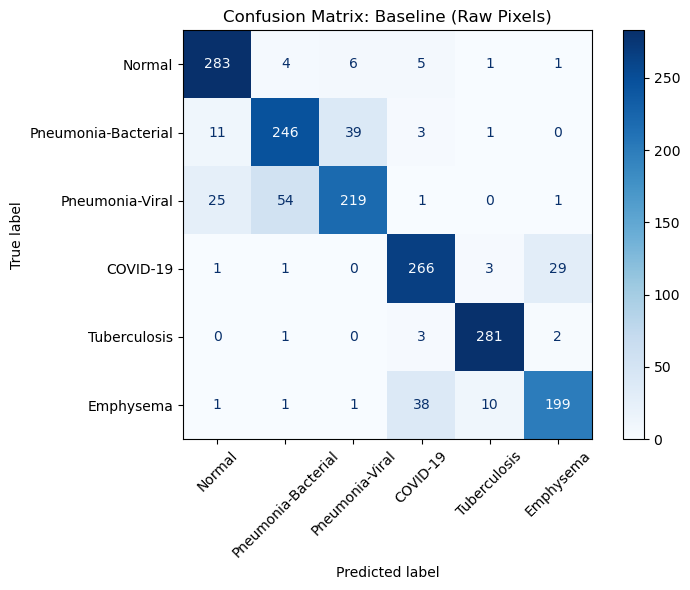

In [17]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

# Evaluate
y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===

[Combined Model] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.87      0.94      0.90       300
Pneumonia-Bacterial       0.79      0.82      0.80       300
    Pneumonia-Viral       0.82      0.72      0.77       300
           COVID-19       0.83      0.85      0.84       300
       Tuberculosis       0.95      0.97      0.96       287
          Emphysema       0.82      0.77      0.79       250

           accuracy                           0.85      1737
          macro avg       0.85      0.84      0.84      1737
       weighted avg       0.85      0.85      0.84      1737



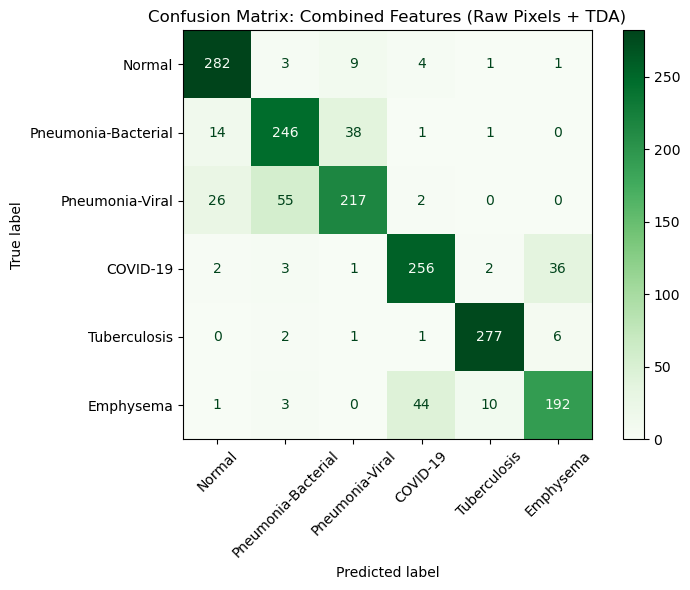

In [18]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
# Concatenate raw pixel features and topological features
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

# Evaluate
y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()

=== Visualizing Average Persistent Landscapes per Disease Class ===


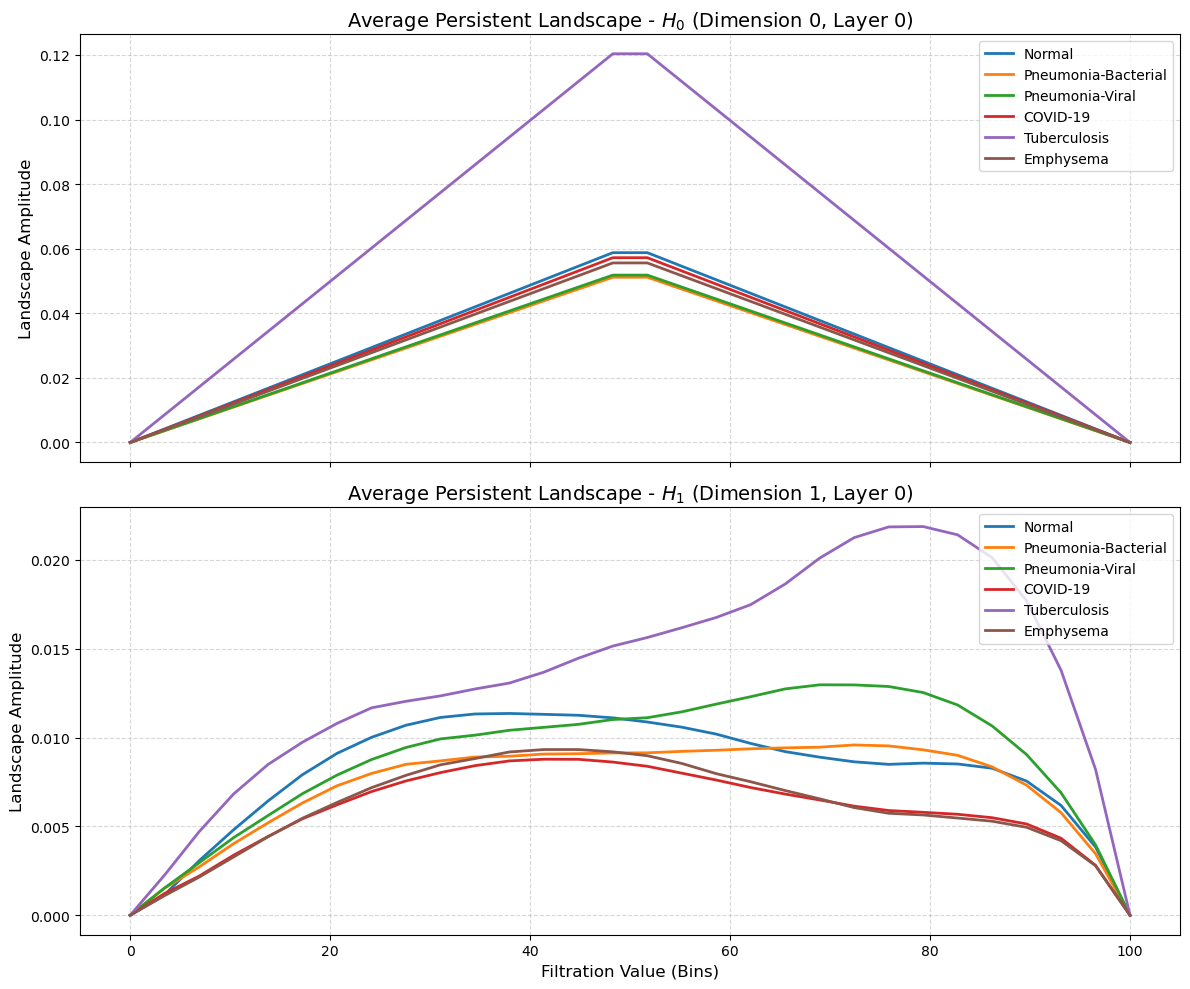

In [19]:
print("=== Visualizing Average Persistent Landscapes per Disease Class ===")

# Extract the landscape vectors from the TDA array (located at index 100 to 220)
# Shape configuration: 2 homology dimensions (H0, H1) * 2 layers * 30 bins = 120 features
landscapes_flat = X_train_tda[:, 100:220]
landscapes = landscapes_flat.reshape(-1, 2, 2, 30)

bins = np.linspace(0, 100, 30)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Compute and plot the mean landscape for each class
for class_idx, class_name in enumerate(CLASSES):
    class_mask = (y_train == class_idx)
    if not np.any(class_mask):
        continue
        
    # Average across axis 0 (samples belonging to the specific class)
    mean_landscape = np.mean(landscapes[class_mask], axis=0) # Resulting shape: (2, 2, 30)
    
    # Plot Layer 0 for H0
    axes[0].plot(bins, mean_landscape[0, 0, :], label=class_name, lw=2)
    # Plot Layer 0 for H1
    axes[1].plot(bins, mean_landscape[1, 0, :], label=class_name, lw=2)

# Format H0 Subplot
axes[0].set_title("Average Persistent Landscape - $H_0$ (Dimension 0, Layer 0)", fontsize=14)
axes[0].set_ylabel("Landscape Amplitude", fontsize=12)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Format H1 Subplot
axes[1].set_title("Average Persistent Landscape - $H_1$ (Dimension 1, Layer 0)", fontsize=14)
axes[1].set_xlabel("Filtration Value (Bins)", fontsize=12)
axes[1].set_ylabel("Landscape Amplitude", fontsize=12)
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
# The flat array presumably has the shape (n_samples, 200)
X_train_flat = np.load("TRAIN_LANDSCAPES_X.npy")
y_train = np.load("TRAIN_LANDSCAPES_y.npy")
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']

# ==========================================
# 2. RESHAPE TO GIOTTO-TDA TENSOR FORMAT
# ==========================================
# giotto-tda outputs persistence landscapes as: (n_samples, n_homology_dims, n_layers, n_bins)
# 200 features = 2 homology dims (H0, H1) * 2 layers (L1, L2) * 50 bins
n_samples = X_train_flat.shape[0]
X_train_4d = X_train_flat.reshape((n_samples, 2, 2, 50))

# giotto-tda standard indexing:
# Homology dimensions: 0 -> H0, 1 -> H1
# Landscape layers:    0 -> L1, 1 -> L2
H1_IDX = 1
L1_IDX = 0

# ==========================================
# 3. PLOTTING SETUP
# ==========================================
plt.figure(figsize=(14, 7))
t_vals = np.linspace(0, 100, 50) 
colors = plt.cm.tab10(np.linspace(0, 1, len(classes))) # Better visual distinction

# ==========================================
# 4. DATA AGGREGATION & VISUALIZATION
# ==========================================
for i, class_name in enumerate(classes):
    # Filter by class directly from the 4D tensor
    # Shape: (n_samples_in_class, 2, 2, 50)
    class_data_4d = X_train_4d[y_train == i]
    
    # Calculate the mean across the patient axis (axis=0)
    # Shape: (2, 2, 50)
    mean_landscape_4d = np.mean(class_data_4d, axis=0)
    
    # Extract H1 L1 directly using named indices
    mean_H1_L1 = mean_landscape_4d[H1_IDX, L1_IDX, :]
    
    plt.plot(t_vals, mean_H1_L1, label=f"{class_name} (n={len(class_data_4d)})", 
             linewidth=2.5, color=colors[i])

# Formatting 
plt.title("Average Persistence Landscape $L_1$ ($H_1$) by Medical Class", fontsize=14, pad=15)
plt.xlabel("Filtration Parameter $t$", fontsize=12)
plt.ylabel("Average Landscape Amplitude", fontsize=12)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Clean up top/right spines for a more academic look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

ValueError: cannot reshape array of size 3288526 into shape (14551,2,2,50)

CUBICAL

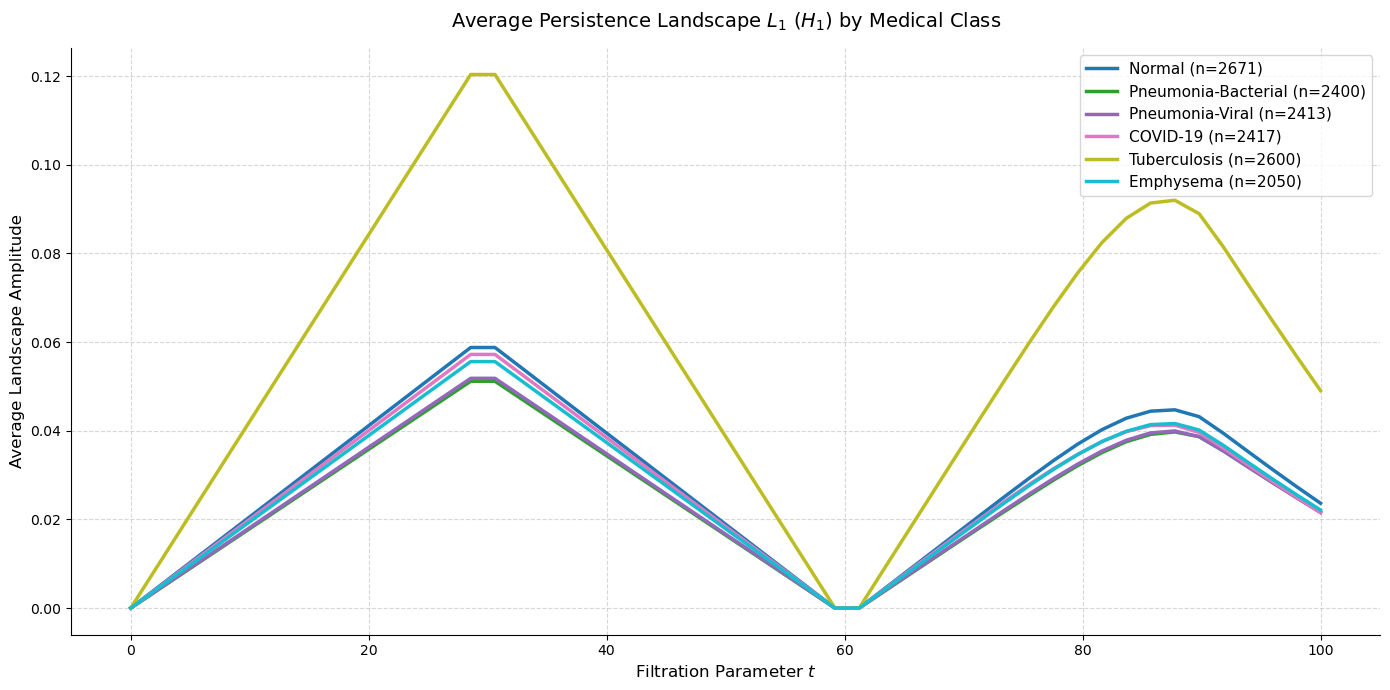

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD REAL DATA
# ==========================================
X_train_flat = np.load("TRAIN_LANDSCAPES_X.npy")
y_train = np.load("TRAIN_LANDSCAPES_y.npy")
classes = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']

# Safeguard: dynamically calculate the correct number of features
n_samples = 14551
n_features = X_train_flat.size // n_samples  # This evaluates to 226 automatically

# Restore the 2D shape (14551 patients x 226 features)
X_train_2d = X_train_flat.reshape((n_samples, n_features))

# ==========================================
# 2. PLOTTING SETUP & DATA AGGREGATION
# ==========================================
plt.figure(figsize=(14, 7))
t_vals = np.linspace(0, 100, 50) 
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, class_name in enumerate(classes):
    # Extract data for a specific class (2D matrix)
    class_data = X_train_2d[y_train == i]
    
    # Average across all patients in this class (along columns)
    mean_vector = np.mean(class_data, axis=0)
    
    # Extract only the indices 100:150 (assuming this is H1 L1)
    mean_H1_L1 = mean_vector[100:150]
    
    plt.plot(t_vals, mean_H1_L1, label=f"{class_name} (n={len(class_data)})", 
             linewidth=2.5, color=colors[i])

# ==========================================
# 3. CHART FORMATTING
# ==========================================
plt.title("Average Persistence Landscape $L_1$ ($H_1$) by Medical Class", fontsize=14, pad=15)
plt.xlabel("Filtration Parameter $t$", fontsize=12)
plt.ylabel("Average Landscape Amplitude", fontsize=12)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Clean up top/right spines for a more academic look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from gtda.homology import CubicalPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

# def extract_features_cubical(image_path, target_size=(32, 32)):
def extract_features_cubical(image_path, target_size=(128, 128)):
    """
    Loads an image, processes it as a 2D height map (hologram),
    calculates Cubical Homology, and extracts exactly 226 TDA features.
    """
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    # Resize and normalize pixel intensities to [0, 1]
    img_resized = cv2.resize(img, target_size)
    pixel_intensities = img_resized / 255.0
    raw_pixels = pixel_intensities.flatten()
    
    try:
        # CubicalPersistence expects a 3D tensor: (n_samples, width, height)
        image_tensor = np.expand_dims(pixel_intensities, axis=0)
        
        # 1. Compute Persistence Diagrams natively on the 2D grid
        cp = CubicalPersistence(homology_dimensions=[0, 1], n_jobs=1)
        diagrams = cp.fit_transform(image_tensor)
        
        # 2. Handle the essential class (infinity)
        # The base connected component never dies. We cap its death at max filtration value (1.0)
        diagrams[np.isinf(diagrams)] = 1.0
        
        # 3. Extract Topological Features
        bc = BettiCurve(n_bins=50).fit_transform(diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    
def process_dataset_split_cubical(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    # Run parallel processing across available CPU cores
    results = Parallel(n_jobs=-1)(delayed(extract_features_cubical)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [38]:
# Execute processing for all dataset splits
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_cubical('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_cubical('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_cubical('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...
[VAL] Found 1748 images. Processing...
[TEST] Found 1737 images. Processing...
Feature extraction finished successfully.


In [39]:
np.save("TRAIN_LANDSCAPES_CUB_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_CUB_y.npy", y_train)

np.save("VAL_LANDSCAPES_CUB_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_CUB_y.npy", y_val)

np.save("TEST_LANDSCAPES_CUB_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_CUB_y.npy", y_test)

=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===



[Baseline] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.89      0.95      0.92       300
Pneumonia-Bacterial       0.81      0.81      0.81       300
    Pneumonia-Viral       0.81      0.76      0.78       300
           COVID-19       0.87      0.89      0.88       300
       Tuberculosis       0.95      0.98      0.96       287
          Emphysema       0.87      0.82      0.85       250

           accuracy                           0.87      1737
          macro avg       0.87      0.87      0.87      1737
       weighted avg       0.87      0.87      0.87      1737



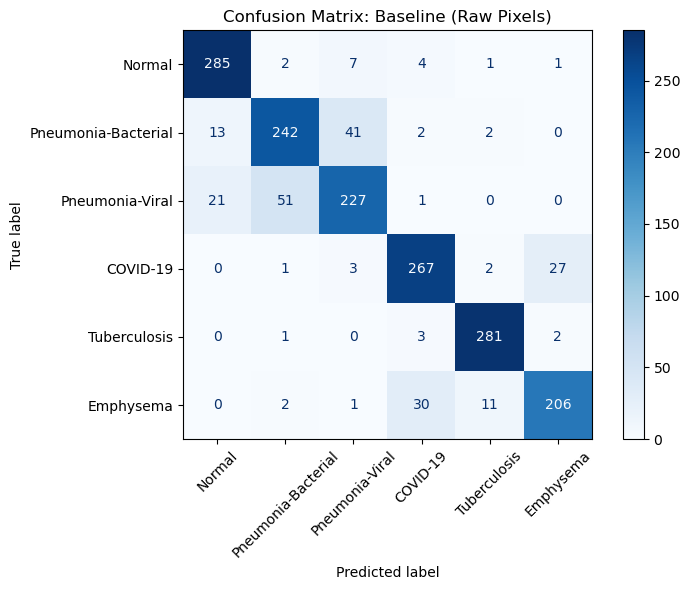

In [40]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

# Evaluate
y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===

[Combined Model] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.89      0.95      0.92       300
Pneumonia-Bacterial       0.82      0.82      0.82       300
    Pneumonia-Viral       0.83      0.77      0.80       300
           COVID-19       0.85      0.89      0.87       300
       Tuberculosis       0.96      0.98      0.97       287
          Emphysema       0.88      0.82      0.85       250

           accuracy                           0.87      1737
          macro avg       0.87      0.87      0.87      1737
       weighted avg       0.87      0.87      0.87      1737



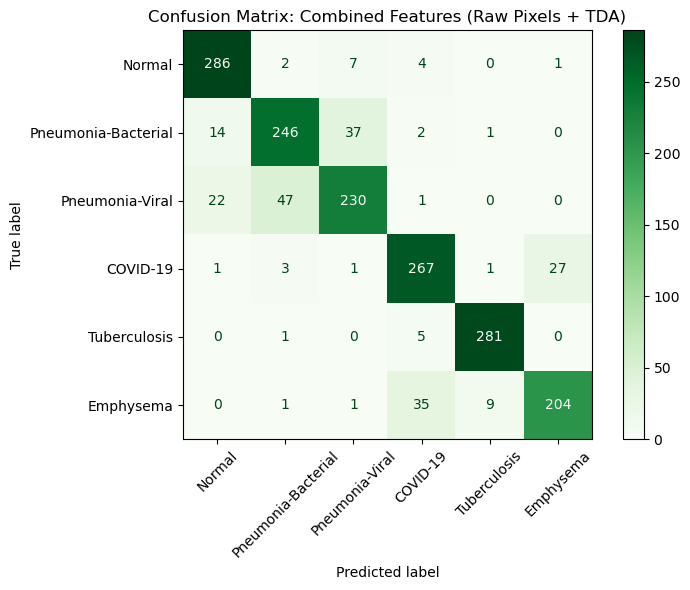

In [41]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
# Concatenate raw pixel features and topological features
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

# Evaluate
y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()

VR 3D

In [32]:
import cv2
import numpy as np
from ripser import ripser
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_3d_rips(image_path, target_size=(32, 32)):
    """
    Loads an image, treats it as a 3D hologram (X, Y spatial, Z intensity),
    calculates Vietoris-Rips Homology via direct C++ Ripser, 
    and extracts exactly 226 TDA features.
    """
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    # Resize and normalize pixel intensities to [0, 1] for the Z-axis
    img_resized = cv2.resize(img, target_size)
    z_intensity = img_resized / 255.0
    raw_pixels = z_intensity.flatten()
    
    try:
        # 1. X and Y axes: Normalize spatial coordinates to [0, 1]
        x_coords = np.linspace(0, 1, target_size[1])
        y_coords = np.linspace(0, 1, target_size[0])
        xv, yv = np.meshgrid(x_coords, y_coords)
        
        # 2. Create Point Cloud: Shape (N, 3) -> [x_pos, y_pos, intensity]
        point_cloud_3d = np.column_stack((xv.flatten(), yv.flatten(), raw_pixels))
        
        # 3. Compute Persistence Diagrams directly via fast C++ Ripser wrapper
        ripser_res = ripser(point_cloud_3d, maxdim=1)
        dgms = ripser_res['dgms']
        
        # 4. Format Ripser output for giotto-tda feature extractors
        # Remove infinity from H0 (essential component) to avoid NaN errors in gtda
        h0 = dgms[0][dgms[0][:, 1] != np.inf]
        h1 = dgms[1]
        
        # Add a third column representing the homology dimension (0 for H0, 1 for H1)
        if h0.shape[0] > 0:
            h0_ext = np.column_stack((h0, np.zeros(h0.shape[0])))
        else:
            h0_ext = np.empty((0, 3))
            
        if h1.shape[0] > 0:
            h1_ext = np.column_stack((h1, np.ones(h1.shape[0])))
        else:
            h1_ext = np.empty((0, 3))
            
        # Combine H0 and H1, then add the batch dimension -> shape: (1, n_points, 3)
        dgm_combined = np.vstack((h0_ext, h1_ext))
        gtda_diagrams = np.expand_dims(dgm_combined, axis=0)
        
        # 5. Extract Topological Features
        bc = BettiCurve(n_bins=50).fit_transform(gtda_diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(gtda_diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(gtda_diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(gtda_diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(gtda_diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    
def process_dataset_split_rips3d(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    # Run parallel processing across available CPU cores
    results = Parallel(n_jobs=-1)(delayed(extract_features_3d_rips)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [33]:
# Execute processing for all dataset splits
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_rips3d('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_rips3d('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_rips3d('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...
[VAL] Found 1748 images. Processing...
[TEST] Found 1737 images. Processing...
Feature extraction finished successfully.


In [34]:
np.save("TRAIN_LANDSCAPES_VR3D_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_VR3D_y.npy", y_train)

np.save("VAL_LANDSCAPES_VR3D_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_VR3D_y.npy", y_val)

np.save("TEST_LANDSCAPES_VR3D_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_VR3D_y.npy", y_test)

=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===

[Baseline] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.88      0.94      0.91       300
Pneumonia-Bacterial       0.80      0.82      0.81       300
    Pneumonia-Viral       0.83      0.73      0.78       300
           COVID-19       0.84      0.89      0.86       300
       Tuberculosis       0.95      0.98      0.96       287
          Emphysema       0.86      0.80      0.83       250

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737



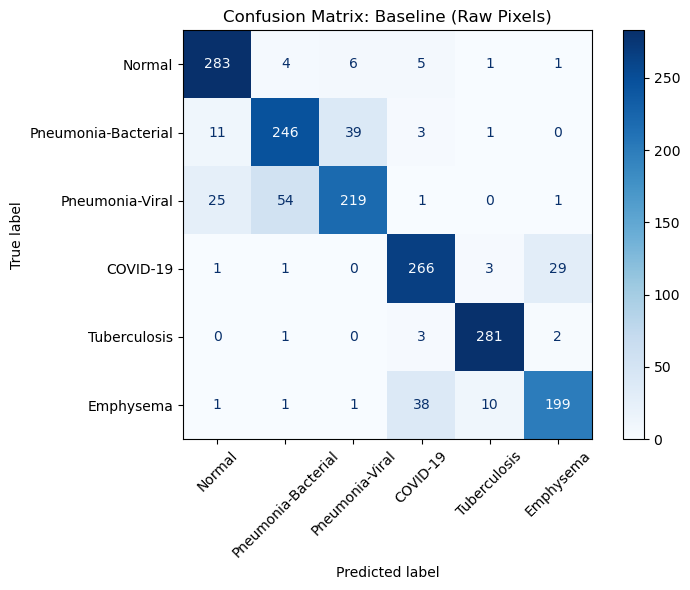

In [35]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

# Evaluate
y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===

[Combined Model] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.87      0.95      0.91       300
Pneumonia-Bacterial       0.79      0.81      0.80       300
    Pneumonia-Viral       0.82      0.72      0.77       300
           COVID-19       0.86      0.89      0.88       300
       Tuberculosis       0.96      0.99      0.98       287
          Emphysema       0.88      0.81      0.84       250

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737



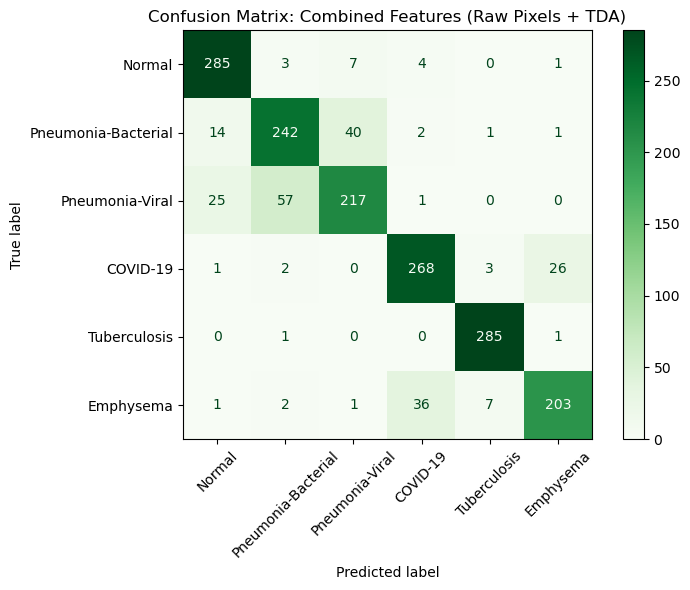

In [36]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
# Concatenate raw pixel features and topological features
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

# Evaluate
y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import subprocess
import tempfile
import os
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_3d_rips_cpp(image_path, target_size=(32, 32)):
    """
    Loads an image, treats it as a 3D hologram (X, Y spatial, Z intensity),
    calculates Vietoris-Rips Homology via a direct call to the C++ ripser executable, 
    and extracts exactly 226 TDA features.
    """
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    # Resize and normalize pixel intensities to [0, 1] for the Z-axis
    img_resized = cv2.resize(img, target_size)
    z_intensity = img_resized / 255.0
    raw_pixels = z_intensity.flatten()
    
    temp_filename = None
    try:
        # 1. X and Y axes: Normalize spatial coordinates to [0, 1]
        x_coords = np.linspace(0, 1, target_size[1])
        y_coords = np.linspace(0, 1, target_size[0])
        xv, yv = np.meshgrid(x_coords, y_coords)
        
        # 2. Create Point Cloud: Shape (N, 3) -> [x_pos, y_pos, intensity]
        point_cloud_3d = np.column_stack((xv.flatten(), yv.flatten(), raw_pixels))
        
        # 3. Save point cloud to a temporary text file for the C++ Ripser executable
        with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
            for pt in point_cloud_3d:
                f.write(f"{pt[0]} {pt[1]} {pt[2]}\n")
            temp_filename = f.name
            
        # 4. Call the external C++ Ripser executable
        # --dim 1 computes both H0 and H1
        # --format point-cloud tells it to expect coordinates, not a distance matrix
        cmd = ["../../ripser/ripser", "--format", "point-cloud", "--dim", "1", temp_filename]
        
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        ripser_output = result.stdout
        
        # 5. Parse the C++ Ripser string output into NumPy arrays
        h0_list, h1_list = [], []
        current_dim = -1
        
        for line in ripser_output.splitlines():
            line = line.strip()
            if line.startswith("persistence intervals in dim 0:"):
                current_dim = 0
            elif line.startswith("persistence intervals in dim 1:"):
                current_dim = 1
            elif line.startswith("["):
                # Parse interval format, e.g., "[0.1, 0.4)" or "[0, )"
                clean_line = line.replace('[', '').replace(')', '').replace(' ', '')
                parts = clean_line.split(',')
                if len(parts) == 2:
                    birth = float(parts[0])
                    death_str = parts[1]
                    
                    if death_str == '' or 'inf' in death_str.lower() or '∞' in death_str:
                        death = np.inf
                    else:
                        death = float(death_str)
                        
                    if current_dim == 0:
                        h0_list.append([birth, death])
                    elif current_dim == 1:
                        h1_list.append([birth, death])
                        
        h0 = np.array(h0_list) if h0_list else np.empty((0, 2))
        h1 = np.array(h1_list) if h1_list else np.empty((0, 2))
        
        # 6. Format Ripser output for giotto-tda feature extractors
        # Remove infinity from H0 (essential component) to avoid NaN errors in gtda
        h0_filtered = h0[h0[:, 1] != np.inf] if h0.shape[0] > 0 else h0
        
        # Add a third column representing the homology dimension (0 for H0, 1 for H1)
        if h0_filtered.shape[0] > 0:
            h0_ext = np.column_stack((h0_filtered, np.zeros(h0_filtered.shape[0])))
        else:
            h0_ext = np.empty((0, 3))
            
        if h1.shape[0] > 0:
            h1_ext = np.column_stack((h1, np.ones(h1.shape[0])))
        else:
            h1_ext = np.empty((0, 3))
            
        # Combine H0 and H1, then add the batch dimension -> shape: (1, n_points, 3)
        dgm_combined = np.vstack((h0_ext, h1_ext))
        gtda_diagrams = np.expand_dims(dgm_combined, axis=0)
        
        # 7. Extract Topological Features
        bc = BettiCurve(n_bins=50).fit_transform(gtda_diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(gtda_diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(gtda_diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(gtda_diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(gtda_diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except subprocess.CalledProcessError as e:
        print(f"Ripser C++ execution error on {image_path}: {e.stderr}")
        return raw_pixels, default_tda
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    finally:
        # Clean up the temporary file from the disk
        if temp_filename and os.path.exists(temp_filename):
            os.remove(temp_filename)

    
def process_dataset_split_rips3d_cpp(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    # Run parallel processing across available CPU cores
    results = Parallel(n_jobs=-1)(delayed(extract_features_3d_rips_cpp)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [ ]:
# Execute processing for all dataset splits
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_rips3d_cpp('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_rips3d_cpp('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_rips3d_cpp('test')
print("Feature extraction finished successfully.")

In [ ]:
np.save("TRAIN_LANDSCAPES_VR3D_cpp_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_VR3D_cpp_y.npy", y_train)

np.save("VAL_LANDSCAPES_VR3D_cpp_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_VR3D_cpp_y.npy", y_val)

np.save("TEST_LANDSCAPES_VR3D_cpp_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_VR3D_cpp_y.npy", y_test)

In [ ]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

# Evaluate
y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

In [ ]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
# Concatenate raw pixel features and topological features
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

# Evaluate
y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()